Hér verða líkön þjálfuð eins og líst er í aðferðafræði skýrslunnar. Þjálfuð verða líkön sem forvinna textagögnin með TF-IDF og síðan verða eftirfarnandi ML aðferðir notaðar:


*   Logistic Regression
*   Random Forest
*   Naive Bayes
*   Multi Layer Perceprtion



# Næ í gögnin

In [4]:
import os
import json
import pandas as pd
import data_utils

emails_df = data_utils.get_ephish()

Loaded data succesfully (16616 emails) from data/ephish_emails.json
Count of emails by 'type':
type
1    5996
0    5506
Name: count, dtype: int64

Percentage breakdown:
Normal emails (type 0): 47.87%
Phishing emails (type 1): 52.13%



# TF-IDF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Separate text data for Subject and Body
X_subject_text = emails_df['Subject']
X_body_text = emails_df['Body']
y = emails_df['type']

# Initialize TF-IDF Vectorizers for Subject and Body
tfidf_vectorizer_subject = TfidfVectorizer()
tfidf_vectorizer_body = TfidfVectorizer()

# Fit and transform Subject data
X_subject_tfidf = tfidf_vectorizer_subject.fit_transform(X_subject_text)

# Fit and transform Body data
X_body_tfidf = tfidf_vectorizer_body.fit_transform(X_body_text)

# Combine the TF-IDF features from Subject and Body
X_tfidf = hstack([X_subject_tfidf, X_body_tfidf])

print(f"Shape of combined TF-IDF matrix: {X_tfidf.shape}")

# Split the dataset into training and testing sets only
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of combined TF-IDF matrix: (11502, 17236)
Shape of X_train: (9201, 17236)
Shape of X_test: (2301, 17236)
Shape of y_train: (9201,)
Shape of y_test: (2301,)


# Logistic Regression
Heimildir:

*   [Context-Aware Phishing Email Detection Using Machine Learning and NLP](https://arxiv.org/abs/2603.27326)


Logistic Regression Model Performance on Test Set:
Accuracy: 0.9913081269013473

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1101
           1       1.00      0.99      0.99      1200

    accuracy                           0.99      2301
   macro avg       0.99      0.99      0.99      2301
weighted avg       0.99      0.99      0.99      2301



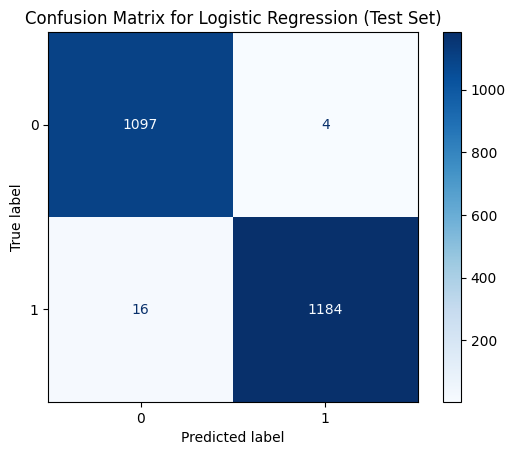

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model on the training data
log_history = log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = log_reg_model.predict(X_test)

# Evaluate the model on the test set
print("Logistic Regression Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression (Test Set)')
plt.show()

In [7]:
import pandas as pd

# Get feature names from both vectorizers
subject_features = tfidf_vectorizer_subject.get_feature_names_out()
body_features = tfidf_vectorizer_body.get_feature_names_out()


# Combine feature names in the same order as X_tfidf was stacked
feature_names = list(subject_features) + list(body_features)

# Get the coefficients from the Logistic Regression model
# For binary classification, coef_ is usually a 1D array or 2D array with 1 row.
coefficients = log_reg_model.coef_[0]

# Create a DataFrame to store ture names and their coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to find the most influential words
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Influential Words (Positive Coefficients - indicating type 1/phishing):")
display(coef_df[coef_df['Coefficient'] > 0].head(20))

print("\nTop 10 Most Influential Words (Negative Coefficients - indicating type 0/normal):")
display(coef_df[coef_df['Coefficient'] < 0].head(20))

Top 10 Most Influential Words (Positive Coefficients - indicating type 1/phishing):


,Feature,Coefficient,Abs_Coefficient
10997,link,8.206893,8.206893
4929,attached,4.679200,4.679200
2672,quick,4.105812,4.105812
7351,document,4.050422,4.050422
2781,required,3.911603,3.911603
1250,exclusive,3.858722,3.858722
8494,find,3.329742,3.329742
7403,download,3.286681,3.286681
1686,immediate,3.238118,3.238118
4931,attachment,3.071572,3.071572



Top 10 Most Influential Words (Negative Coefficients - indicating type 0/normal):


,Feature,Coefficient,Abs_Coefficient
290,and,-2.870841,2.870841
9880,in,-2.548920,2.548920
15949,these,-2.489668,2.489668
1327,feedback,-2.316560,2.316560
4613,and,-2.262773,2.262773
5148,be,-2.054292,2.054292
13324,provide,-2.027833,2.027833
1755,inquiry,-1.964133,1.964133
12023,next,-1.943408,1.943408
12356,our,-1.916260,1.916260


## Test Model with Custom Input

In [8]:
# Get user input for subject and body
custom_subject = "Varðandi meðmæli"
custom_body = "Sæll Garðar\nNú er ég að útskrifast og mig vantar meðmæli við útskriftina\nEndilega hafðu samband við mig fljótlega. Ég læt viðhengi fylgja. Brýnt er að ég skili þessu sem fyrst, hér er hlekkur til að senda inn umsóknina: <<link>>.\nMbk. Axel"

# Transform the custom input using the *trained* TF-IDF vectorizers
custom_subject_tfidf = tfidf_vectorizer_subject.transform([custom_subject])
custom_body_tfidf = tfidf_vectorizer_body.transform([custom_body])

# Combine the transformed features in the same way as the training data
import scipy.sparse
custom_X_tfidf = scipy.sparse.hstack([custom_subject_tfidf, custom_body_tfidf])

# Make a prediction using the trained Logistic Regression model
prediction = log_reg_model.predict(custom_X_tfidf)

# Interpret and print the prediction
if prediction[0] == 0:
    print("\nThe model predicts this is a: Normal Email (0)")
elif prediction[0] == 1:
    print("\nThe model predicts this is a: Phishing Email (1)")
else:
    print(f"\nUnexpected prediction: {prediction[0]}")


The model predicts this is a: Phishing Email (1)


# Random Forest

Random Forest Classifier Model Performance on Test Set:
Accuracy: 0.9765319426336375

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1101
           1       0.98      0.98      0.98      1200

    accuracy                           0.98      2301
   macro avg       0.98      0.98      0.98      2301
weighted avg       0.98      0.98      0.98      2301



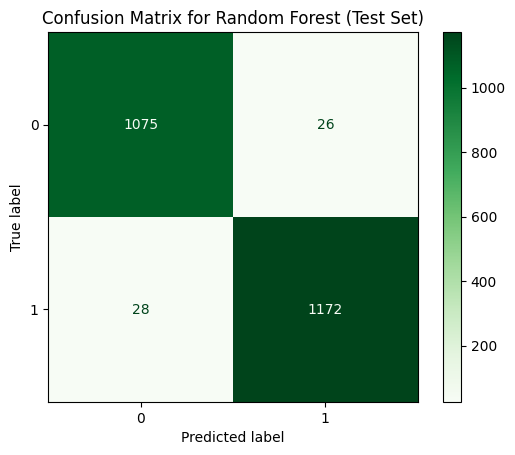

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier model
# Using a reasonable number of estimators; can be tuned later.
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_rf = random_forest_model.predict(X_test)

# Evaluate the model on the test set
print("Random Forest Classifier Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_rf))

# Generate and display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_test_rf, labels=random_forest_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Random Forest (Test Set)')
plt.show()

Naive Bayes

Naive Bayes Model Performance on Test Set:
Accuracy: 0.9587136027813994

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      1101
           1       0.99      0.93      0.96      1200

    accuracy                           0.96      2301
   macro avg       0.96      0.96      0.96      2301
weighted avg       0.96      0.96      0.96      2301



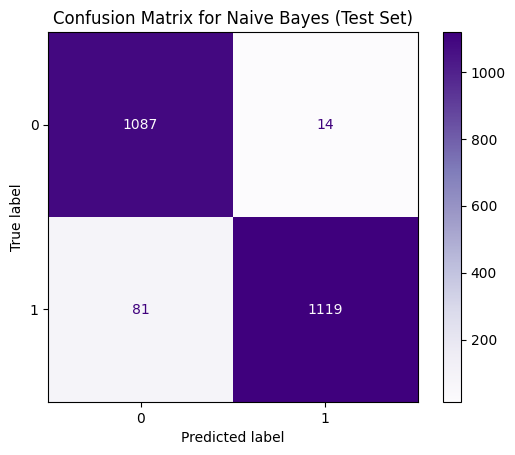

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Multinomial Naive Bayes model
# MultinomialNB is well-suited for classification with discrete features (like word counts or TF-IDF scores).
naive_bayes_model = MultinomialNB()

# Train the model on the training data
naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_nb = naive_bayes_model.predict(X_test)

# Evaluate the model on the test set
print("Naive Bayes Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_nb))

# Generate and display the confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_test_nb, labels=naive_bayes_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=naive_bayes_model.classes_)
disp_nb.plot(cmap=plt.cm.Purples)
plt.title('Confusion Matrix for Naive Bayes (Test Set)')
plt.show()

# Multi Layer Perceptron

Multi Layer Perceptron Model Performance on Test Set:
Accuracy: 0.9926119078661452

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1101
           1       1.00      0.99      0.99      1200

    accuracy                           0.99      2301
   macro avg       0.99      0.99      0.99      2301
weighted avg       0.99      0.99      0.99      2301



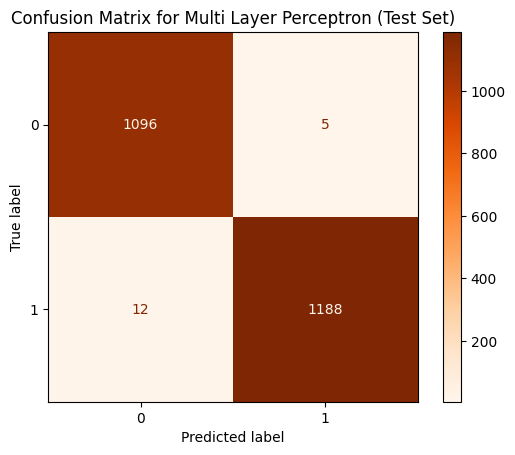

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Multi Layer Perceptron classifier
# Using default parameters for initial testing. These can be tuned later.
mlp_model = MLPClassifier(random_state=42, max_iter=200, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, verbose=False)

# Train the model on the training data
mlp_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_mlp = mlp_model.predict(X_test)

# Evaluate the model on the test set
print("Multi Layer Perceptron Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_mlp))

# Generate and display the confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_test_mlp, labels=mlp_model.classes_)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_model.classes_)
disp_mlp.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix for Multi Layer Perceptron (Test Set)')
plt.show()

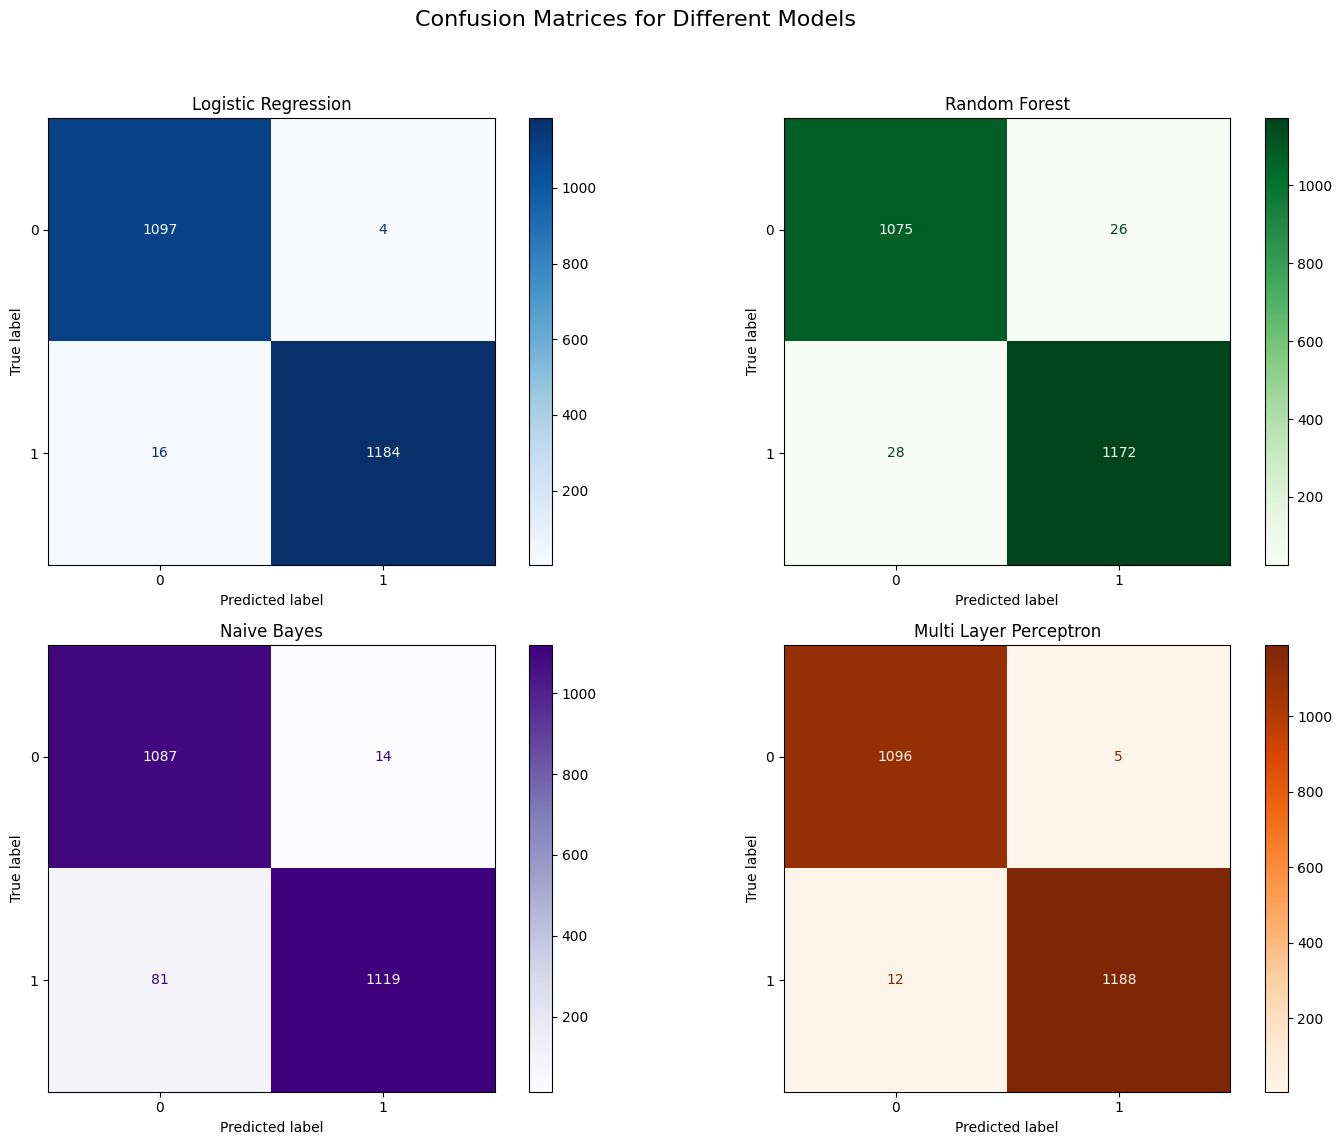

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Confusion Matrices for Different Models', fontsize=16)

# Plot Logistic Regression Confusion Matrix
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp_log_reg.plot(cmap=plt.cm.Blues, ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')

# Plot Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp_rf.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title('Random Forest')

# Plot Naive Bayes Confusion Matrix
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=naive_bayes_model.classes_)
disp_nb.plot(cmap=plt.cm.Purples, ax=axes[1, 0])
axes[1, 0].set_title('Naive Bayes')

# Plot Multi Layer Perceptron Confusion Matrix
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_model.classes_)
disp_mlp.plot(cmap=plt.cm.Oranges, ax=axes[1, 1])
axes[1, 1].set_title('Multi Layer Perceptron')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [14]:
from sklearn.metrics import f1_score
import pandas as pd

# Calculate F1 scores for each model and class
f1_log_reg_0 = f1_score(y_test, y_pred_test, pos_label=0)
f1_log_reg_1 = f1_score(y_test, y_pred_test, pos_label=1)

f1_rf_0 = f1_score(y_test, y_pred_test_rf, pos_label=0)
f1_rf_1 = f1_score(y_test, y_pred_test_rf, pos_label=1)

f1_nb_0 = f1_score(y_test, y_pred_test_nb, pos_label=0)
f1_nb_1 = f1_score(y_test, y_pred_test_nb, pos_label=1)

f1_mlp_0 = f1_score(y_test, y_pred_test_mlp, pos_label=0)
f1_mlp_1 = f1_score(y_test, y_pred_test_mlp, pos_label=1)

# Create a DataFrame for better readability
f1_scores_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'Multi Layer Perceptron'],
    'F1 Score (Class 0 - Normal)': [f1_log_reg_0, f1_rf_0, f1_nb_0, f1_mlp_0],
    'F1 Score (Class 1 - Phishing)': [f1_log_reg_1, f1_rf_1, f1_nb_1, f1_mlp_1]
})

print("F1 Scores Comparison on Test Set:")
print(f1_scores_df.to_string(index=False))

F1 Scores Comparison on Test Set:
                 Model  F1 Score (Class 0 - Normal)  F1 Score (Class 1 - Phishing)
   Logistic Regression                     0.990967                       0.991625
         Random Forest                     0.975499                       0.977481
           Naive Bayes                     0.958131                       0.959280
Multi Layer Perceptron                     0.992304                       0.992896


Loaded data succesfully (16616 emails) from data/ephish_emails.json
Count of emails by 'type':
type
1    5996
0    5506
Name: count, dtype: int64

Percentage breakdown:
Normal emails (type 0): 47.87%
Phishing emails (type 1): 52.13%

Starting experiment with 9 distributions...

Processing distribution 1:9 (Normal:Phishing). Normal samples: 550, Phishing samples: 5396
Class distribution in current dataset:
 type
1    5396
0     550
Name: count, dtype: int64
  Training Logistic Regression...
    F1 (Class 0): 0.8900, Precision (Class 0): 0.9889, Recall (Class 0): 0.8091
    F1 (Class 1): 0.9899, Precision (Class 1): 0.9809, Recall (Class 1): 0.9991
  Training Random Forest...
    F1 (Class 0): 0.7283, Precision (Class 0): 1.0000, Recall (Class 0): 0.5727
    F1 (Class 1): 0.9787, Precision (Class 1): 0.9583, Recall (Class 1): 1.0000
  Training Naive Bayes...
    F1 (Class 0): 0.7624, Precision (Class 0): 0.9718, Recall (Class 0): 0.6273
    F1 (Class 1): 0.9804, Precision (Class 1): 0.96

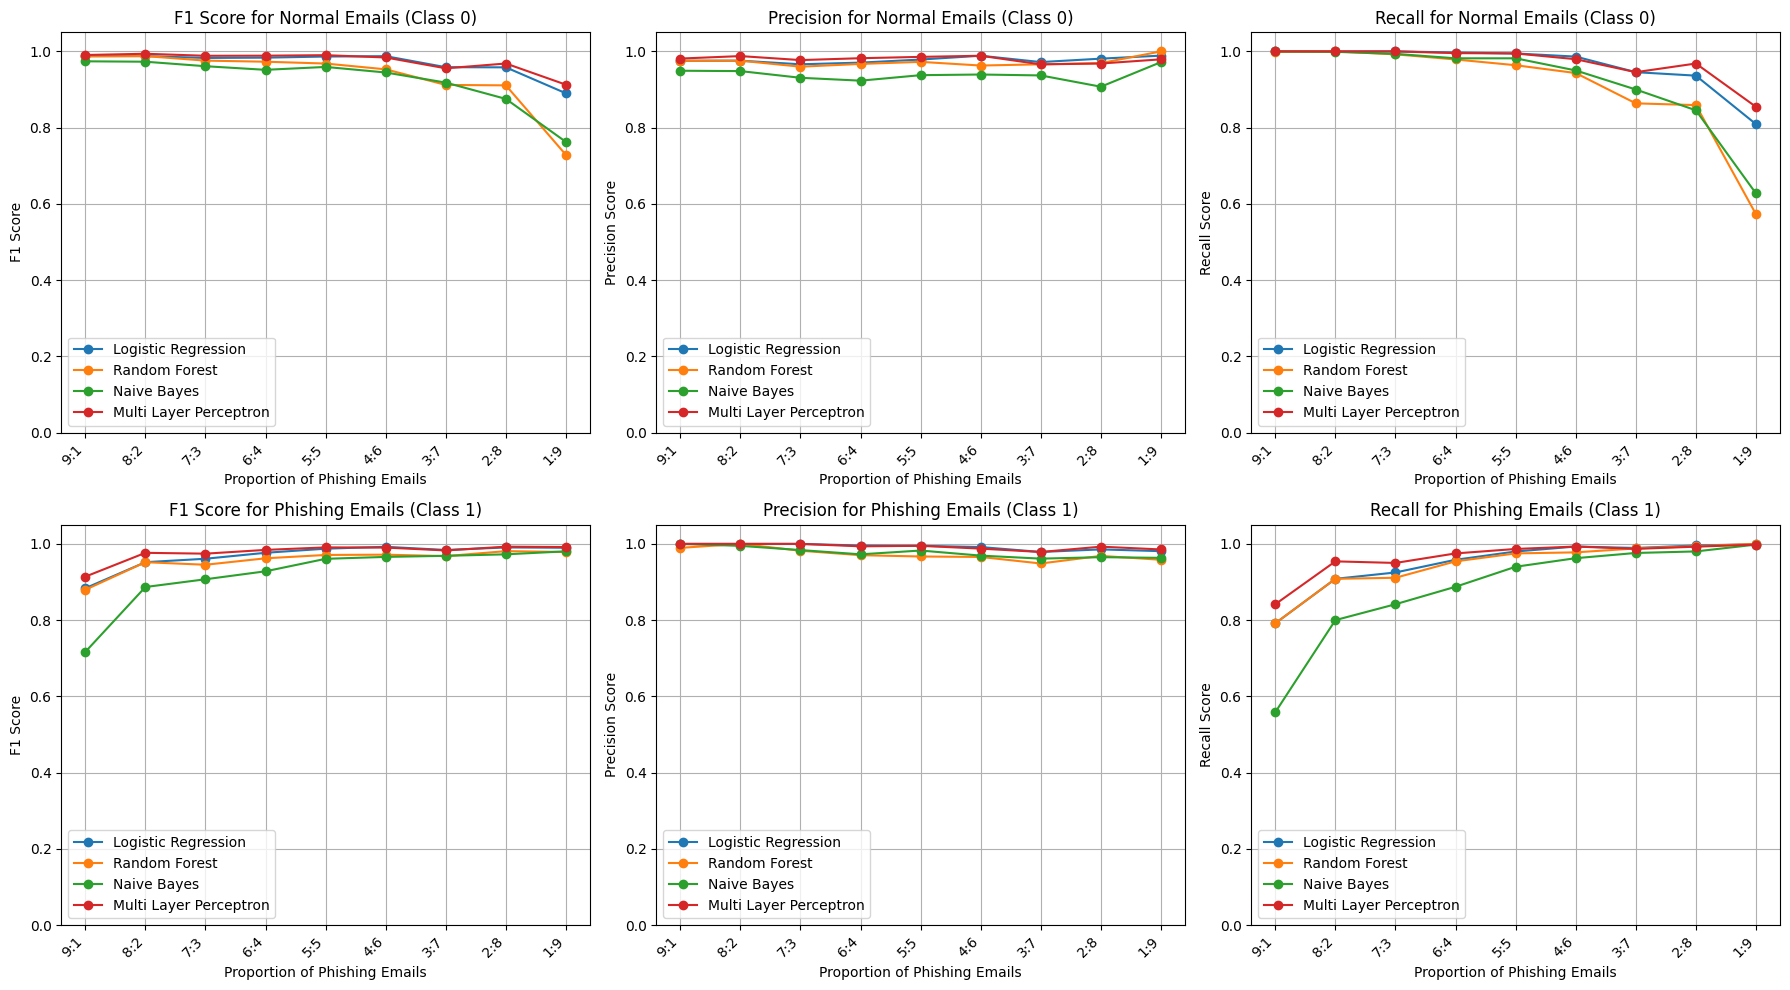

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, precision_score, recall_score # Added precision_score and recall_score
import matplotlib.pyplot as plt
import numpy as np
import os # Added for data loading
import json # Added for data loading

# --- Start of added code to ensure emails_df is defined ---
# Get data (from cell ledep4SS4g_O)

emails_df = data_utils.get_ephish()
# --- End of added code ---

# Store results
results = []
distributions_for_plot = [] # To store the (phishing_proportion) for x-axis values

# Define the ratios (Normal:Phishing)
ratios = [(1, 9), (2, 8), (3, 7), (4, 6), (5, 5), (6, 4), (7, 3), (8, 2), (9, 1)]

# Separate original data by type (assuming emails_df is already loaded)
df_normal_all = emails_df[emails_df['type'] == 0]
df_phishing_all = emails_df[emails_df['type'] == 1]

# Determine the maximum number of samples available for each class from the original dataset
# This ensures we don't try to sample more than what's available for the larger class
max_normal_samples = len(df_normal_all)
max_phishing_samples = len(df_phishing_all)

print(f"Starting experiment with {len(ratios)} distributions...")

for r0, r1 in ratios:
    phishing_proportion = r1 / (r0 + r1)
    distributions_for_plot.append(phishing_proportion)

    # Calculate the desired total number of samples based on the *smallest* class count
    # and the desired ratio sum (r0 + r1) to maintain proportionality while respecting data limits.
    ratio_sum = r0 + r1
    
    num_normal_actual = int(max_normal_samples * (r0 / (r0 + r1)))
    num_phishing_actual = int(max_phishing_samples * (r1 / (r0 + r1)))

    # Ensure we don't end up with zero samples if one ratio is zero, though ratios are 1-9 here.
    if num_normal_actual == 0 and r0 > 0: num_normal_actual = 1 # Minimum 1 sample if ratio > 0
    if num_phishing_actual == 0 and r1 > 0: num_phishing_actual = 1 # Minimum 1 sample if ratio > 0

    # Sample from the original dataframes
    df_normal_sampled = df_normal_all.sample(n=num_normal_actual, random_state=42)
    df_phishing_sampled = df_phishing_all.sample(n=num_phishing_actual, random_state=42)

    current_df = pd.concat([df_normal_sampled, df_phishing_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\nProcessing distribution {r0}:{r1} (Normal:Phishing). Normal samples: {len(df_normal_sampled)}, Phishing samples: {len(df_phishing_sampled)}")
    print("Class distribution in current dataset:\n", current_df['type'].value_counts())

    # TF-IDF Vectorization
    X_subject_text_curr = current_df['Subject']
    X_body_text_curr = current_df['Body']
    y_curr = current_df['type']

    tfidf_vectorizer_subject_exp = TfidfVectorizer() # Use new vectorizers for each distribution
    tfidf_vectorizer_body_exp = TfidfVectorizer()

    X_subject_tfidf_curr = tfidf_vectorizer_subject_exp.fit_transform(X_subject_text_curr)
    X_body_tfidf_curr = tfidf_vectorizer_body_exp.fit_transform(X_body_text_curr)
    X_tfidf_curr = hstack([X_subject_tfidf_curr, X_body_tfidf_curr])

    # Train-test split (80% train, 20% test, stratified)
    X_train_curr, X_test_curr, y_train_curr, y_test_curr = train_test_split(X_tfidf_curr, y_curr, test_size=0.2, random_state=42, stratify=y_curr)

    # Models to train and evaluate
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000), # Increased max_iter for convergence
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "Naive Bayes": MultinomialNB(),
        "Multi Layer Perceptron": MLPClassifier(random_state=42, max_iter=200, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, verbose=False)
    }

    for model_name, model in models.items():
        print(f"  Training {model_name}...")
        model.fit(X_train_curr, y_train_curr)
        y_pred_curr = model.predict(X_test_curr)

        # Calculate metrics for class 0 (Normal)
        f1_0 = f1_score(y_test_curr, y_pred_curr, pos_label=0)
        precision_0 = precision_score(y_test_curr, y_pred_curr, pos_label=0, zero_division=0)
        recall_0 = recall_score(y_test_curr, y_pred_curr, pos_label=0, zero_division=0)

        # Calculate metrics for class 1 (Phishing)
        f1_1 = f1_score(y_test_curr, y_pred_curr, pos_label=1)
        precision_1 = precision_score(y_test_curr, y_pred_curr, pos_label=1, zero_division=0)
        recall_1 = recall_score(y_test_curr, y_pred_curr, pos_label=1, zero_division=0)

        results.append({
            'Distribution_Ratio_Normal_Phishing': f"{r0}:{r1}",
            'Phishing_Proportion': phishing_proportion,
            'Model': model_name,
            'F1_Class_0': f1_0,
            'Precision_Class_0': precision_0,
            'Recall_Class_0': recall_0,
            'F1_Class_1': f1_1,
            'Precision_Class_1': precision_1,
            'Recall_Class_1': recall_1
        })
        print(f"    F1 (Class 0): {f1_0:.4f}, Precision (Class 0): {precision_0:.4f}, Recall (Class 0): {recall_0:.4f}")
        print(f"    F1 (Class 1): {f1_1:.4f}, Precision (Class 1): {precision_1:.4f}, Recall (Class 1): {recall_1:.4f}")

results_df = pd.DataFrame(results)
print("\n--- Experiment Results Summary ---")
print(results_df.to_string(index=False))

# Plotting
plt.figure(figsize=(18, 10)) # Increased figure size for more plots

# F1 for Class 0 (Normal)
plt.subplot(2, 3, 1) # Changed to 2 rows, 3 columns
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['F1_Class_0'], label=model_name, marker='o')
plt.title('F1 Score for Normal Emails (Class 0)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('F1 Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Precision for Class 0 (Normal)
plt.subplot(2, 3, 2)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['Precision_Class_0'], label=model_name, marker='o')
plt.title('Precision for Normal Emails (Class 0)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('Precision Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Recall for Class 0 (Normal)
plt.subplot(2, 3, 3)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['Recall_Class_0'], label=model_name, marker='o')
plt.title('Recall for Normal Emails (Class 0)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('Recall Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# F1 for Class 1 (Phishing)
plt.subplot(2, 3, 4)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['F1_Class_1'], label=model_name, marker='o')
plt.title('F1 Score for Phishing Emails (Class 1)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('F1 Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Precision for Class 1 (Phishing)
plt.subplot(2, 3, 5)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['Precision_Class_1'], label=model_name, marker='o')
plt.title('Precision for Phishing Emails (Class 1)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('Precision Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Recall for Class 1 (Phishing)
plt.subplot(2, 3, 6)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Phishing_Proportion')
    plt.plot(model_data['Phishing_Proportion'], model_data['Recall_Class_1'], label=model_name, marker='o')
plt.title('Recall for Phishing Emails (Class 1)')
plt.xlabel('Proportion of Phishing Emails')
plt.ylabel('Recall Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()